# 电影情感分类实战_subword分词_LSTM

In [2]:
#pip install datasets
from datasets import load_dataset
import os

dataset = load_dataset("imdb")

# 确保 data2 文件夹存在
os.makedirs("data", exist_ok=True)

def save_to_txt(split, file_prefix):
    texts = dataset[split]['text']
    labels = dataset[split]['label']
    # 分别写入文本文件，每一行为一个样本或标签
    with open(f"data/{file_prefix}_{split}_texts.txt", "w", encoding="utf-8") as f_text, \
         open(f"data/{file_prefix}_{split}_labels.txt", "w", encoding="utf-8") as f_label:
        # 遍历数据集的每个样本
        for text, label in zip(texts, labels):
            # 替换换行符 使每行代表一个样本
            text = text.replace('\n', ' ').replace('\r', ' ')  # \r 代表 回车符
            f_text.write(text + "\n")
            f_label.write(str(label) + "\n")
    print(f"{split} set saved: data/{file_prefix}_{split}_texts.txt, data/{file_prefix}_{split}_labels.txt")

save_to_txt("train", "imdb")
save_to_txt("test", "imdb")

train set saved: data/imdb_train_texts.txt, data/imdb_train_labels.txt
test set saved: data/imdb_test_texts.txt, data/imdb_test_labels.txt


## 读取数据，sub-word 分词，构建词典

In [1]:
# 使用 subword-nmt 学习 BPE 和词汇表
!subword-nmt learn-joint-bpe-and-vocab -i ./data/imdb_train_texts.txt -o ./data/imdb_bpe_code --write-vocabulary ./data/imdb_bpe_vocab -s 8000


100%|##########| 8000/8000 [00:39<00:00, 204.64it/s]


In [ ]:
# 依赖规则表，将原始文本切分为 BPE 子词格式
!subword-nmt apply-bpe -c ./data/imdb_bpe_code -i ./data/imdb_train_texts.txt -o ./data/imdb_train_bpe.txt
!subword-nmt apply-bpe -c ./data/imdb_bpe_code -i ./data/imdb_test_texts.txt -o ./data/imdb_test_bpe.txt

In [1]:
# 从 BPE 词汇表文件构建词典，保留词频大于等于1的词
vocab_file = './data/imdb_bpe_vocab'

# 读取词汇表文件，格式：word 词频
vocab_words = []
with open(vocab_file, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()  # 去除行首尾的空白字符
        # 如果行是空行，则跳过
        if not line:
            continue
        # 分割词和词频
        parts = line.rsplit(' ', 1)  # 从右边分割一次，处理词中包含空格的情况
        if len(parts) == 2:
            word, freq = parts
            freq = int(freq)
            # 保留词频大于等于1的词
            if freq >= 1:
                vocab_words.append(word)

# 添加特殊符号
special_tokens = ['<pad>', '<unk>', '<bos>', '<eos>']
vocab_words = special_tokens + vocab_words

# 构建 word2idx 和 idx2word 字典映射
word2idx = {word: idx for idx, word in enumerate(vocab_words)}
idx2word = {idx: word for word, idx in word2idx.items()}

# 查看词典信息
vocab_size = len(vocab_words)
print(f"词典大小: {vocab_size}")
print(f"特殊符号: {special_tokens}")
print(f"查看word2idx词典")
print(f"前10个词和索引: {list(word2idx.items())[:10]}")
print(f"后10个词和索引: {list(word2idx.items())[-10:]}")
print(f"查看idx2word词典")
print(f"前10个索引和词: {list(idx2word.items())[:10]}")
print(f"后10个索引和词: {list(idx2word.items())[-10:]}")

词典大小: 8299
特殊符号: ['<pad>', '<unk>', '<bos>', '<eos>']
查看word2idx词典
前10个词和索引: [('<pad>', 0), ('<unk>', 1), ('<bos>', 2), ('<eos>', 3), ('the', 4), ('a', 5), ('and', 6), ('of', 7), ('to', 8), ('is', 9)]
后10个词和索引: [('\x80@@', 8289), ('\xad@@', 8290), ('ï', 8291), ('Ø@@', 8292), ('ê', 8293), ('ë', 8294), ('Õ', 8295), ('³@@', 8296), ('Inste@@', 8297), ('°@@', 8298)]
查看idx2word词典
前10个索引和词: [(0, '<pad>'), (1, '<unk>'), (2, '<bos>'), (3, '<eos>'), (4, 'the'), (5, 'a'), (6, 'and'), (7, 'of'), (8, 'to'), (9, 'is')]
后10个索引和词: [(8289, '\x80@@'), (8290, '\xad@@'), (8291, 'ï'), (8292, 'Ø@@'), (8293, 'ê'), (8294, 'ë'), (8295, 'Õ'), (8296, '³@@'), (8297, 'Inste@@'), (8298, '°@@')]


imdb_test_bpe.txt 样本总数: 25000
最短的样本长度: 7
最长的样本长度: 3275
平均样本长度: 309.92
中位数样本长度: 229.0
样本长度标准差: 239.27


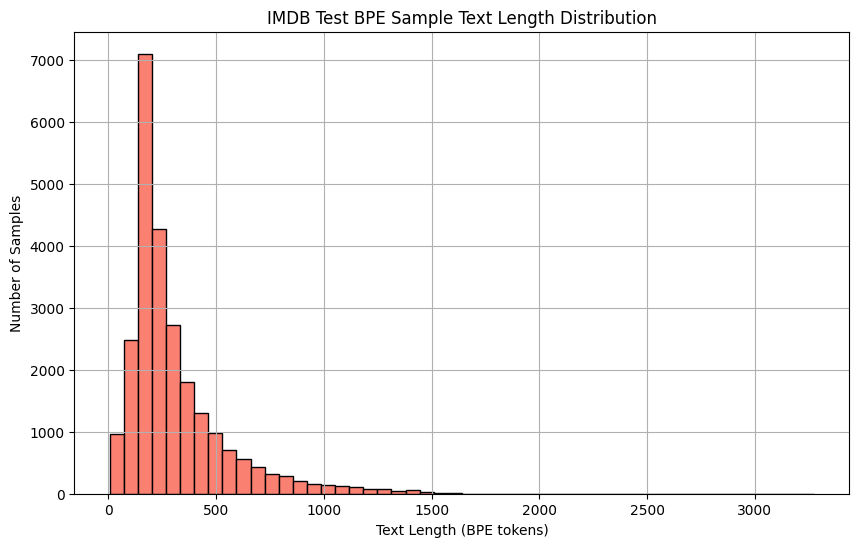

In [2]:
# 统计imdb_test_bpe.txt文件中每条样本的长度

test_bpe_file = './data/imdb_test_bpe.txt'

# 每条样本一行，按空格分割为BPE token
test_sample_lengths = []
with open(test_bpe_file, 'r', encoding='utf-8') as f:
    for line in f:
        tokens = line.strip().split()  # 按空格分割为BPE token
        test_sample_lengths.append(len(tokens))

# 打印关键信息
print(f"imdb_test_bpe.txt 样本总数: {len(test_sample_lengths)}")
print(f"最短的样本长度: {min(test_sample_lengths)}")
print(f"最长的样本长度: {max(test_sample_lengths)}")
print(f"平均样本长度: {sum(test_sample_lengths)/len(test_sample_lengths):.2f}")

import numpy as np
print(f"中位数样本长度: {np.median(test_sample_lengths)}")
print(f"样本长度标准差: {np.std(test_sample_lengths):.2f}")

# 绘图显示分布
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(test_sample_lengths, bins=50, color='salmon', edgecolor='black')  # 绘制直方图
plt.title("IMDB Test BPE Sample Text Length Distribution")
plt.xlabel("Text Length (BPE tokens)")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.show()


## 编写Tokenizer

encoder （编码）：把样本变成id

decoder （解码）：把id变成word

In [3]:
# word-level分词，左右去除空格，这里简单按空格切分
def word_tokenize(text):
    return text.strip().split()

In [4]:
class Tokenizer:
    """一个简单的 word-level Tokenizer。

    你可以在初始化时设置默认控制参数（如是否加 BOS/EOS、是否 padding、是否 truncation 等），
    也可以在调用 `encode/decode` 时传参覆盖。
    """

    def __init__(
        self,
        word2idx: dict,
        idx2word: dict,
        tokenize_fn=word_tokenize,
        pad_token: str = '<pad>',
        unk_token: str = '<unk>',
        bos_token: str = '<bos>',
        eos_token: str = '<eos>',
        max_length: int | None = None,
        add_bos: bool = False,
        add_eos: bool = False,
        truncation: bool = True,
        skip_special_tokens: bool = True,
        stop_at_eos: bool = False,
        padding_first: bool = False,
    ):
        """
        初始化 Tokenizer。

        参数说明：
            word2idx (dict): 词到id的映射字典，例如 {'hello':1, ...}
            idx2word (dict): id到词的映射字典，例如 {1:'hello', ...}
            tokenize_fn (callable): 分词函数，输入为字符串，输出为token（词）列表，默认 word_tokenize。
            pad_token (str): 用于补齐长度的特殊符号字符串（默认为'<pad>'），应包含于 word2idx 中。
            unk_token (str): 未知词特殊符号（默认为'<unk>'），应包含于 word2idx 中。
            bos_token (str): 序列开始特殊符号（默认为'<bos>'），应包含于 word2idx 中。
            eos_token (str): 序列结束特殊符号（默认为'<eos>'），应包含于 word2idx 中。
            max_length (int|None): 默认编码输出最大长度，None表示不限长。
            add_bos (bool): 编码时是否自动在序列开头加 BOS。
            add_eos (bool): 编码时是否自动在序列结尾加 EOS。
            truncation (bool): 超长度时是否截断。
            skip_special_tokens (bool): 解码时是否跳过输出特殊符号。
            stop_at_eos (bool): 解码遇到 <eos> 时是否立刻停止解码（不包含eos）。
            padding_first (bool): padding是否在序列前面添加，False表示在后面添加（默认）。
        """
        self.word2idx = word2idx
        self.idx2word = idx2word
        self.tokenize_fn = tokenize_fn

        # 特殊符号
        self.pad_token = pad_token
        self.unk_token = unk_token
        self.bos_token = bos_token
        self.eos_token = eos_token

        # 特殊符号对应 id
        self.pad_id = self.word2idx[self.pad_token]
        self.unk_id = self.word2idx[self.unk_token]
        self.bos_id = self.word2idx[self.bos_token]
        self.eos_id = self.word2idx[self.eos_token]

        # 默认控制参数（调用时若传 None，则使用这些默认值）
        self.max_length = max_length
        self.add_bos = add_bos
        self.add_eos = add_eos
        self.truncation = truncation
        self.skip_special_tokens = skip_special_tokens
        self.stop_at_eos = stop_at_eos
        self.padding_first = padding_first

    def encode(
        self,
        texts: list[str],
        max_length: int | None = None,
        add_bos: bool | None = None,
        add_eos: bool | None = None,
        truncation: bool | None = None,
        padding_first: bool | None = None,
    ):
        """
        将文本编码为 id 序列。

        参数说明：
            texts (lsit[str]): 待编码的一批样本
            max_length (int|None): 目标id序列长度；为 None 时使用初始化的 max_length，若仍为 None，则不做截断或补齐。
            add_bos (bool|None): 是否添加 BOS（<bos>）特殊符号，None表示用类的默认设定。
            add_eos (bool|None): 是否添加 EOS（<eos>）特殊符号，None表示用类的默认设定。
            truncation (bool|None): 是否对超长的id序列截断至max_length，None用类默认值。
            padding_first (bool|None): padding是否在序列前面添加，None表示用类的默认设定。

        返回：
            ids (List[int]): 编码后的id序列（按要求加上特殊符号/截断/补齐）。
        """
        # 若未传入则使用实例的默认参数
        if max_length is None:
            max_length = self.max_length
        if add_bos is None:
            add_bos = self.add_bos
        if add_eos is None:
            add_eos = self.add_eos
        if truncation is None:
            truncation = self.truncation
        if padding_first is None:
            padding_first = self.padding_first

        batch_ids = []
        for text in texts:
            tokens = self.tokenize_fn(text)  # 用分词函数把文本拆成token(词)

            # token 映射到 id，不在词表里用unk_id
            ids = [self.word2idx.get(t, self.unk_id) for t in tokens]

            # 可选: 在序列开头/结尾加BOS/EOS
            if add_bos:
                ids = [self.bos_id] + ids
            if add_eos:
                ids = ids + [self.eos_id]

            batch_ids.append(ids)  # 把该样本的id序列加入batch_id列表

        # 根据 本批次样本的最大长度 和 max_length 中较小者进行截断和补齐
        max_len_in_batch = max(len(x) for x in batch_ids)  # 获取本批次样本的最大长度
        if max_length is not None:
            pad_len = min(max_len_in_batch, max_length)  # 取本批次样本最大长度和max_length中较小者
        else:
            pad_len = max_len_in_batch  # 若max_length为None，则取本批次样本最大长度

        padded_ids = []  # 存储填充后的id序列
        # 遍历本批次所有样本
        for ids in batch_ids:
            # 如果需要截断，则保留前pad_len个
            if truncation and len(ids) > pad_len:
                ids = ids[:pad_len]
            # 补齐：根据 padding_first 决定在前面还是后面添加 padding
            if len(ids) < pad_len:
                pad_count = pad_len - len(ids)
                if padding_first:
                    ids = [self.pad_id] * pad_count + ids
                else:
                    ids = ids + [self.pad_id] * pad_count
            padded_ids.append(ids)  # 将处理后的id序列添加到结果列表

        return padded_ids  # 返回token id列表，每个样本长度均为当前批次pad_len

    def decode(
        self,
        batch_ids,
        skip_special_tokens: bool | None = None,
        stop_at_eos: bool | None = None,
    ):
        """
        将 id 序列解码回文本。

        参数说明：
            batch_ids: List[List[int]]，2维列表，每个内部列表是一个样本的token ids
            skip_special_tokens (bool|None): 解码时是否跳过 <pad>/<unk>/<bos>/<eos>，即输出时不包含这些特殊符号。None采用实例默认值。
            stop_at_eos (bool|None): 解码时遇到 <eos> 是否马上停止（不再继续输出后续token），None采用实例默认值。

        返回：
            text (list[str]): 解码后的文本（token用空格拼接）。
        """
        # 用实例参数的默认值（如果没有明确传参）
        if skip_special_tokens is None:
            skip_special_tokens = self.skip_special_tokens
        if stop_at_eos is None:
            stop_at_eos = self.stop_at_eos

        # 需要跳过的特殊id集合
        special_ids = {self.pad_id, self.unk_id, self.bos_id, self.eos_id} if skip_special_tokens else set()

        results = []
        for ids in batch_ids:
            if hasattr(ids, 'tolist'):  # for torch.Tensor，对tensor转为list
                ids = ids.tolist()
            
            words = []
            for i in ids:
                # 可选: 解码遇到eos时立即停止
                if stop_at_eos and i == self.eos_id:
                    break
                # 若需跳过特殊符号则不输出
                if i in special_ids:
                    continue
                # id映射为词，若没在字典则输出unk_token
                words.append(self.idx2word.get(i, self.unk_token))

            results.append(' '.join(words)) # 用空格拼接所有words

        return results  # 返回每个样本解码后的字符串列表


**使用一个简单的示例测试 Tokenizer 类**

In [5]:
import random

with open("data/imdb_train_bpe.txt", "r", encoding="utf-8") as f:
    train_texts = f.readlines()

# 先通过上面的类实例化 tokenizer 对象
tokenizer = Tokenizer(word2idx,idx2word,max_length=600,skip_special_tokens=False)  # 传入需要的参数

# 对每个样本encode
batch_token_ids = tokenizer.encode(train_texts[0:3],padding_first=True)
print("\nencode后token id:")
for i, tids in enumerate(batch_token_ids):
    print(f"样本{i+1} token ids:", tids)
    print(f"样本{i+1} 长度:", len(tids))

print('-'*50)
decoded_texts = tokenizer.decode(batch_token_ids)
print("\ndecode后文本:")
for i, text in enumerate(decoded_texts):
    print(f"样本{i+1} 解码文本:", text)


encode后token id:
样本1 token ids: [11, 3683, 11, 132, 1838, 94, 398, 2976, 1831, 62, 46, 345, 4301, 1735, 2792, 38, 79, 942, 3070, 119, 7, 40, 4, 8013, 1736, 12, 3142, 3401, 14, 69, 14, 16, 146, 1590, 10, 2340, 6856, 11, 142, 1122, 12, 32, 146, 14, 16, 263, 135, 1018, 33, 5978, 6403, 386, 60, 78, 14, 204, 1672, 8, 4743, 13, 2883, 128, 5559, 176, 5, 807, 7, 247, 2642, 37, 7100, 6960, 11, 85, 84, 8, 93, 13, 19, 1508, 7101, 15, 150, 238, 9, 1701, 1974, 379, 5, 373, 7327, 671, 1448, 4383, 1545, 4512, 5, 42, 970, 8, 1800, 680, 95, 88, 50, 1146, 231, 2147, 95, 970, 8, 2742, 51, 4188, 1019, 8, 448, 54, 848, 7, 1832, 20, 65, 4, 2189, 7327, 153, 374, 50, 1565, 2164, 3887, 245, 17, 4, 5251, 143, 315, 2566, 6, 5043, 3887, 10, 4, 6027, 459, 203, 233, 231, 359, 5277, 2489, 1033, 841, 6, 3481, 1827, 2301, 1396, 7, 62, 607, 2527, 1881, 325, 50, 81, 3790, 60, 20, 2489, 5252, 95, 49, 1005, 18, 51, 1448, 7788, 1760, 1789, 733, 193, 6, 2618, 2180, 55, 15, 2554, 2567, 122, 50, 11, 132, 1838, 94, 398, 2976,

## DataSet 和Dataloader

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from functools import partial


class IMDBDataset(Dataset):
    """IMDB 文本分类数据集，返回 (text, label)。"""
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # 返回原始文本和标签，真正的编码在 DataLoader 的 collate_fn 里做
        return self.texts[idx], int(self.labels[idx])  # 文件中存的是str，需将labels转成int返回


def collate_fn(batch, tokenizer: Tokenizer, max_length: int = 300):
    """DataLoader 的回调函数：把一批 (text, label) 打包成模型可直接使用的 tensor。

    参数：
    - batch: List[(text, label)]，DataLoader 自动传入
    - tokenizer: 上面实现的 Tokenizer 实例
    - max_length: 每个样本的最大长度

    返回：
    - input_ids: LongTensor，形状 [batch_size, seq_len]
    - labels: LongTensor，形状 [batch_size]
    """
    texts, labels = zip(*batch)              # 解包成两个 tuple
    # 使用我们自己的 tokenizer 进行批量编码
    batch_ids = tokenizer.encode(list(texts), max_length=max_length)
    
    # PyTorch 的 Tensor（张量）本质上是一个多维数学矩阵，它只能存储数值数据（如整数、浮点数、布尔值）
    # 传入torch.tensor()的labels 必须是 int、float 或 bool 的列表/数组。
    # 在 PyTorch 中，绝大多数涉及索引的操作（如 nn.CrossEntropyLoss 损失计算、torch.nn.Embedding 查表等）都严格要求输入标签必须是 long 类型
    input_ids = torch.tensor(batch_ids, dtype=torch.long)
    labels = torch.tensor(labels, dtype=torch.long)
    return input_ids, labels


def load_data(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        return f.readlines()

# 加载训练、测试数据
train_texts = load_data("data/imdb_train_bpe.txt")
train_labels = load_data("data/imdb_train_labels.txt")
test_texts = load_data("data/imdb_test_bpe.txt")
test_labels = load_data("data/imdb_test_labels.txt")

# 创建 Dataset 实例（训练集和测试集）
train_dataset = IMDBDataset(train_texts, train_labels)
test_dataset = IMDBDataset(test_texts, test_labels)

# 训练集 DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    collate_fn=partial(collate_fn, tokenizer=tokenizer, max_length=500)  # 使用partial绑定参数
)

# 测试集 DataLoader（不打乱）
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    collate_fn=partial(collate_fn, tokenizer=tokenizer, max_length=500)
)

# 简单看一下一个训练 batch
for batch_idx, (input_ids, labels) in enumerate(train_loader):
    print("训练集第一个 batch 的 input_ids 形状:", input_ids.shape)
    print("训练集第一个 batch 的 labels:", labels)
    # 为了输出不要太长，只打印前两个样本前20个 token
    print("训练样本1前20个 token id:", input_ids[0][:20].tolist())
    print("训练样本2前20个 token id:", input_ids[1][:20].tolist())
    break

# 简单看一下一个测试 batch
for batch_idx, (input_ids, labels) in enumerate(test_loader):
    print("测试集第一个 batch 的 input_ids 形状:", input_ids.shape)
    print("测试集第一个 batch 的 labels:", labels)
    # 为了输出不要太长，只打印前两个样本前20个 token
    print("测试样本1前20个 token id:", input_ids[0][:20].tolist())
    print("测试样本2前20个 token id:", input_ids[1][:20].tolist())
    break


训练集第一个 batch 的 input_ids 形状: torch.Size([64, 500])
训练集第一个 batch 的 labels: tensor([0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0,
        1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1])
训练样本1前20个 token id: [11, 4783, 77, 20, 4, 100, 6398, 2914, 250, 5967, 661, 36, 817, 491, 115, 2045, 6, 17, 5, 1626]
训练样本2前20个 token id: [3858, 7, 169, 6190, 9, 5, 926, 23, 32, 6458, 5502, 86, 75, 9, 5, 1109, 2641, 6, 5, 4952]
测试集第一个 batch 的 input_ids 形状: torch.Size([64, 500])
测试集第一个 batch 的 labels: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
测试样本1前20个 token id: [11, 230, 3426, 6, 315, 3411, 8, 501, 77, 18, 5, 7366, 3238, 8139, 2681, 225, 324, 511, 24, 1301]
测试样本2前20个 token id: [2498, 478, 4, 2661, 3609, 7, 5, 588, 960, 43, 560, 78

## 搭建模型_LSTM

In [7]:
import torch.nn as nn
import torch.nn.functional as F

class TextClassifier(nn.Module):
    """
    文本分类模型：Embedding -> LSTM -> Linear
    
    模型架构：
    1. Embedding层：将token id转换为词向量
    2. LSTM层：处理序列信息，捕获长距离依赖
    3. 全连接层：将LSTM输出映射到分类结果
    """
    def __init__(self, vocab_size, embedding_dim, num_classes, padding_idx, hidden_size=64, num_layers=1):
        """
        初始化文本分类模型
        
        Args:
            vocab_size (int): 词表大小，即所有可能的token数量
            embedding_dim (int): 词向量维度，每个token被映射为多少维的向量
            num_classes (int): 分类类别数，IMDB数据集为2（正面/负面）
            padding_idx (int): 填充token的索引，用于忽略padding位置的计算
            hidden_size (int): LSTM隐藏层维度，默认64
            num_layers (int): LSTM层数，默认1层
        """
        super().__init__()
        
        # 1. 词向量嵌入层（Embedding Layer）
        # 将每个token id映射为embedding_dim维的稠密向量
        # padding_idx参数确保填充位置的梯度不会被更新
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=padding_idx)
        
        # 2. LSTM层（Long Short-Term Memory）
        self.lstm = nn.LSTM(
            input_size=embedding_dim,      # 输入维度：词向量维度
            hidden_size=hidden_size,        # 隐藏层维度
            num_layers=num_layers,          # LSTM层数
            batch_first=True,               # 批次维度在前
        )
        
        # 3. 全连接分类层（Fully Connected Layers）
        self.fc1 = nn.Linear(hidden_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, input_ids):
        """
        前向传播过程
        
        Args:
            input_ids (torch.LongTensor): token id序列，形状为 [batch_size, seq_len]
        
        Returns:
            logits (torch.Tensor): 分类logits，形状为 [batch_size, num_classes]
        """
        # Step 1: 词嵌入（Word Embedding）
        # 将token id转换为稠密向量表示
        # 输入: [batch_size, seq_len] -> 输出: [batch_size, seq_len, embedding_dim]
        x = self.embedding(input_ids)
        
        # Step 2: LSTM前向传播
        # LSTM处理序列信息，逐时间步更新隐藏状态和记忆单元
        # output: [batch_size, seq_len, hidden_size] - 每个时间步的隐藏状态
        # (hn, cn): 元组，包含最后一个时间步的状态
        #   - hn: [num_layers, batch_size, hidden_size] - 隐藏状态
        #   - cn: [num_layers, batch_size, hidden_size] - 记忆单元（cell state）
        output, (hn, cn) = self.lstm(x)
        
        # Step 3: 提取序列表示
        # 对于文本分类任务，通常使用最后一个时间步的隐藏状态作为整个序列的表示
        # hn[-1] 取最后一层的隐藏状态，形状为 [batch_size, hidden_size]
        # 注意：也可以使用 output[:, -1, :] 来获取，两者在单层LSTM中结果相同
        last_hidden = hn[-1]  # [batch_size, hidden_size]
        
        # Step 4: 全连接层分类
        # 第一层全连接 + ReLU激活
        x = self.fc1(last_hidden)  # [batch_size, hidden_size] -> [batch_size, 128]
        x = self.relu(x)            # 非线性激活
        
        # 第二层全连接，输出分类logits
        logits = self.fc2(x)        # [batch_size, 128] -> [batch_size, num_classes]
        
        return logits

In [8]:
# 前向计算验证模型
vocab_size = len(word2idx)
num_classes = 1  # IMDB 情感：0/1
embedding_dim = 16

model = TextClassifier(vocab_size=vocab_size,
                       embedding_dim=embedding_dim,
                       num_classes=num_classes,
                       padding_idx=word2idx['<pad>'])  # 填充索引

# 取一个 batch 测试前向传播
for batch_idx, (input_ids, labels) in enumerate(train_loader):
    print("input_ids 形状:", input_ids.shape)
    logits = model(input_ids)  # [B, num_classes]
    print("logits 形状:", logits.shape)
    print("示例 logits:", logits[0])
    break


input_ids 形状: torch.Size([64, 500])
logits 形状: torch.Size([64, 1])
示例 logits: tensor([0.0003], grad_fn=<SelectBackward0>)


## 模型训练及评估

Trainer 初始化完成
设备: cuda
损失函数: BCEWithLogitsLoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
模型名称: imdb_text_embedding_LSTM_classifier
训练集: 25000 个样本, 391 个批次
验证集: 25000 个样本, 391 个批次
早停: 启用 (patience=5, monitor=val_acc, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/imdb_classification)
开始训练模型...

开始训练二分类模型
训练轮数: 40
训练集: 25000 个样本, 391 个批次
验证集: 25000 个样本, 391 个批次
设备: cuda
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
早停: 启用 (patience=5, monitor=val_acc, min_delta=0.001)
模型保存: 保存最佳模型 (保存目录: ./checkpoints/imdb_classification)

Epoch [1/40], Train Loss: 0.6933, Train Acc: 0.5018, Val Loss: 0.6931, Val Acc: 0.5042
Epoch [2/40], Tr

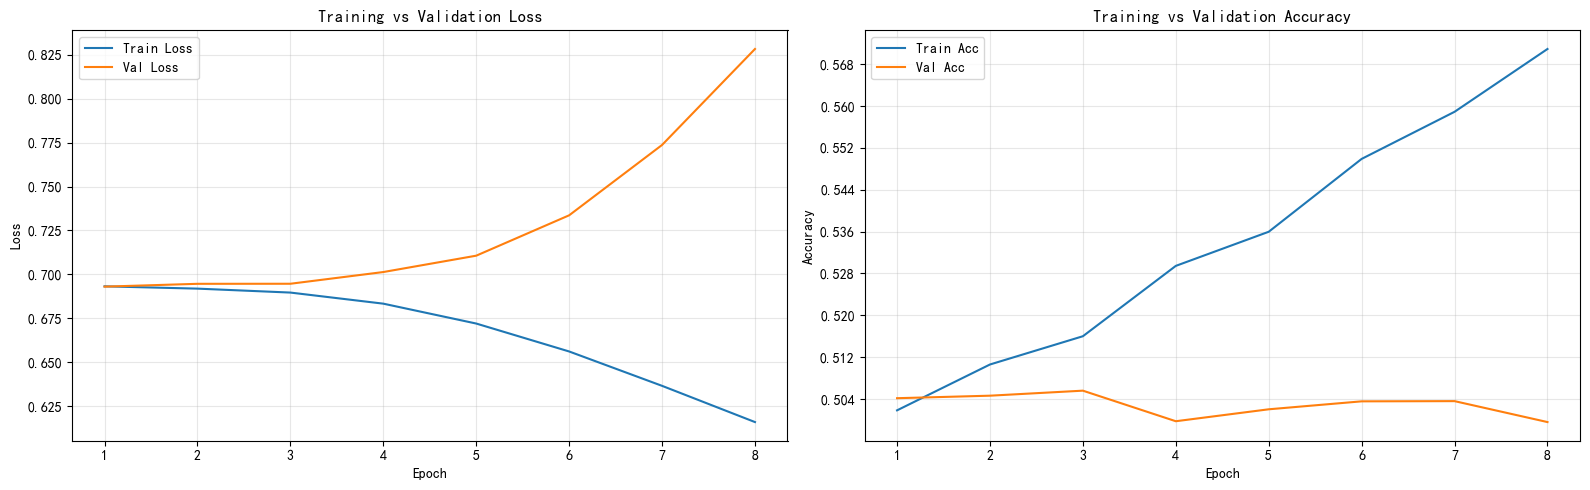

训练历史曲线绘制完成！


In [9]:
# 导入 Train_v5_2 模块
import sys
sys.path.append('.')
from Train_v5_2 import Trainer

# 导入必要的模块
import torch
import torch.nn as nn
import torch.optim as optim

# 创建模型实例
vocab_size = max(word2idx.values()) + 1
num_classes = 1  # IMDB 二分类：0/1
embedding_dim = 16

model = TextClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    num_classes=num_classes,
    padding_idx=word2idx['<pad>']
)

# 创建损失函数（二分类使用BCEWithLogitsLoss）
criterion = nn.BCEWithLogitsLoss()

# 创建优化器（使用Adam）
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 创建 Trainer 实例
trainer = Trainer(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    val_loader=test_loader,
    early_stopping=True,
    patience=5,
    monitor='val_acc',
    min_delta=0.001,
    restore_best_weights=True,
    save_best_model=True,
    save_every_epoch=False,
    save_dir='./checkpoints/imdb_classification',
    model_name='imdb_text_embedding_LSTM_classifier'
)

# 训练模型
print("开始训练模型...")
trainer.train_binary_classification(num_epochs=40, verbose=True)

# 评估模型
print("\n" + "="*60)
print("评估模型性能...")
print("="*60)
val_loss, val_acc = trainer.evaluating_binary_classification()
print(f"\n最终验证结果 - 损失: {val_loss:.4f}, 准确率: {val_acc:.4f}")

# 绘制训练历史曲线
print("\n绘制训练历史曲线...")
trainer.plot_history()
